# Mini Project 1 - Exploratory Data Analysis (EDA)

## Introduction
This dataset represents student placement information for a university. Each row represents an individual student with academic, technical, and communication-related features. The goal of this analysis is to explore the dataset, clean the data, identify relationships between variables, and extract meaningful insights.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student_placement_dataset.csv')
df.head()

,CGPA,Internships,Backlogs,Projects,Coding_Skills,Communication,Attendance,Technical_Test,Aptitude,Confidence,Placement_Status
0,-1.030931,1.391626,0.547274,0.928932,-1.738880,1.250002,1.332551,1.578256,2.124722,-0.318434,0
1,-1.930636,-0.406752,3.061308,1.083145,-2.934634,-1.355054,-1.794192,-0.873019,7.065968,2.110308,0
2,-0.558987,0.299849,1.527071,0.360442,-1.360209,1.100793,-0.755951,1.331933,2.041105,-0.824404,0
3,-1.350289,-2.046078,-0.614264,0.126459,-0.783923,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0
4,-0.275754,-0.728495,0.027727,-0.660834,-1.928161,3.544945,1.446944,-1.111662,0.313766,-2.376528,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CGPA              985 non-null    float64
 1   Internships       985 non-null    float64
 2   Backlogs          1005 non-null   float64
 3   Projects          1005 non-null   float64
 4   Coding_Skills     1005 non-null   float64
 5   Communication     1005 non-null   float64
 6   Attendance        1005 non-null   float64
 7   Technical_Test    1005 non-null   float64
 8   Aptitude          1005 non-null   float64
 9   Confidence        1005 non-null   float64
 10  Placement_Status  1005 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.5 KB


In [4]:
df.describe()

,CGPA,Internships,Backlogs,Projects,Coding_Skills,Communication,Attendance,Technical_Test,Aptitude,Confidence,Placement_Status
count,985.000000,985.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,-0.997510,0.205897,-0.060086,-0.011450,-0.657457,1.597528,-0.025387,0.053059,0.961230,-0.592455,0.201990
std,1.070135,1.560452,1.760811,1.021402,1.781868,2.277724,1.053563,1.796315,2.126978,1.740179,0.401685
min,-4.865140,-5.446468,-5.558615,-3.688365,-7.844223,-5.639699,-3.221016,-6.274085,-5.495407,-5.162097,0.000000
25%,-1.684216,-0.817345,-1.324110,-0.703710,-1.888669,0.007490,-0.749416,-1.111662,-0.438909,-1.757959,0.000000
50%,-1.030931,0.229976,0.001772,-0.027384,-0.674603,1.619910,-0.061098,0.111732,0.718101,-0.610235,0.000000
75%,-0.292761,1.232567,1.177817,0.686957,0.506288,3.308260,0.731898,1.296315,2.247111,0.590576,0.000000
max,2.695232,4.604960,5.526213,3.529055,5.466089,7.860850,2.943048,5.066045,8.826440,5.379806,1.000000


## Phase 2: Data Cleaning
In this phase, we identify missing values, handle duplicates, and prepare the data for analysis.

In [5]:
df.isnull().sum()

CGPA                20
Internships         20
Backlogs             0
Projects             0
Coding_Skills        0
Communication        0
Attendance           0
Technical_Test       0
Aptitude             0
Confidence           0
Placement_Status     0
dtype: int64

### Cleaning Decisions
- Missing values in numerical columns will be filled using the mean value.
- Duplicate rows will be removed to improve data quality.
- No columns were dropped because the missing percentage is very low.

In [6]:
# Fill missing values
df['CGPA'] = df['CGPA'].fillna(df['CGPA'].mean())
df['Internships'] = df['Internships'].fillna(df['Internships'].mean())

# Remove duplicates
df = df.drop_duplicates()

print('Remaining Missing Values:')
print(df.isnull().sum())

print('\nShape after cleaning:', df.shape)

Remaining Missing Values:
CGPA                0
Internships         0
Backlogs            0
Projects            0
Coding_Skills       0
Communication       0
Attendance          0
Technical_Test      0
Aptitude            0
Confidence          0
Placement_Status    0
dtype: int64

Shape after cleaning: (1000, 11)


# Phase 3: Univariate Analysis

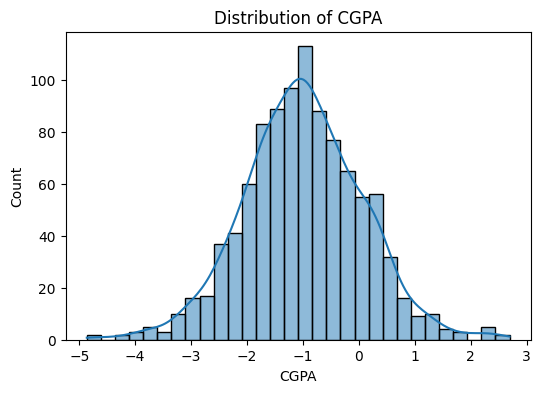

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['CGPA'], bins=30, kde=True)
plt.title('Distribution of CGPA')
plt.show()

The CGPA distribution appears approximately normal with most students clustered around the center. This suggests student academic performance is fairly balanced.

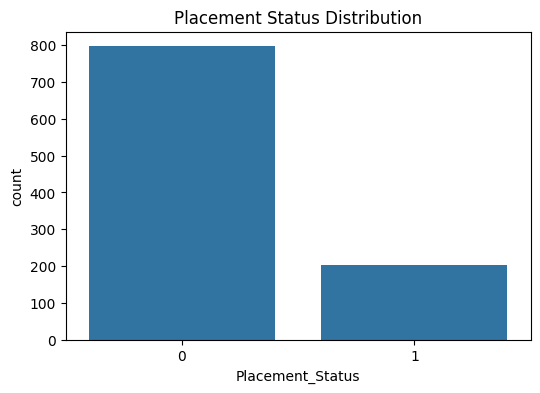

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Placement_Status', data=df)
plt.title('Placement Status Distribution')
plt.show()

The dataset is imbalanced, with more placed students than unplaced students. This reflects realistic placement trends in many universities.

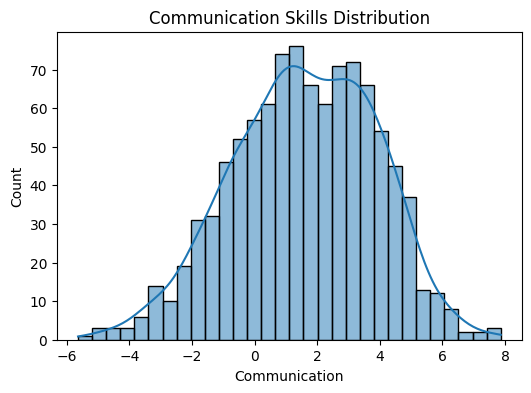

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['Communication'], bins=30, kde=True)
plt.title('Communication Skills Distribution')
plt.show()

Communication skills are distributed across a wide range of values. This may indicate varying interpersonal abilities among students.

# Bivariate Analysis

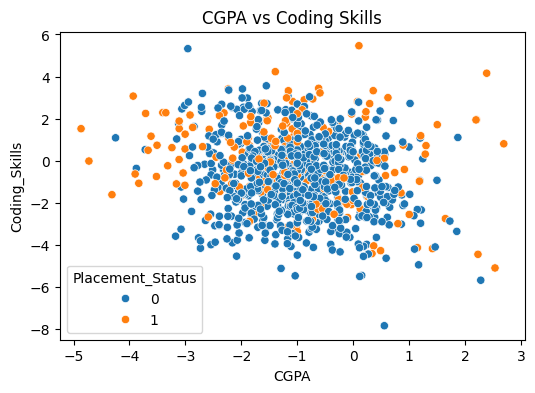

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='CGPA', y='Coding_Skills', hue='Placement_Status', data=df)
plt.title('CGPA vs Coding Skills')
plt.show()

Students with higher CGPA and coding skills appear more likely to be placed. This suggests technical and academic performance influence placements.

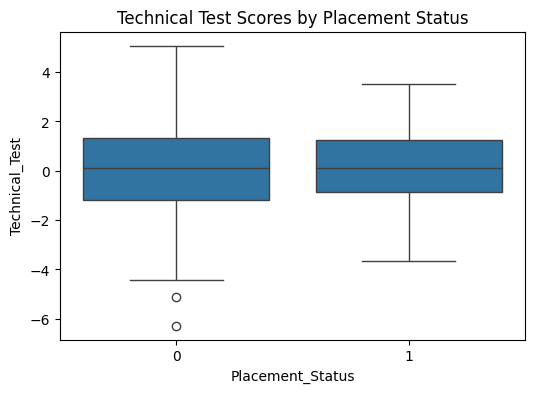

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Placement_Status', y='Technical_Test', data=df)
plt.title('Technical Test Scores by Placement Status')
plt.show()

Placed students generally show higher technical test scores compared to unplaced students. This indicates technical assessments play a major role in placements.

# Phase 4: Multivariate Analysis

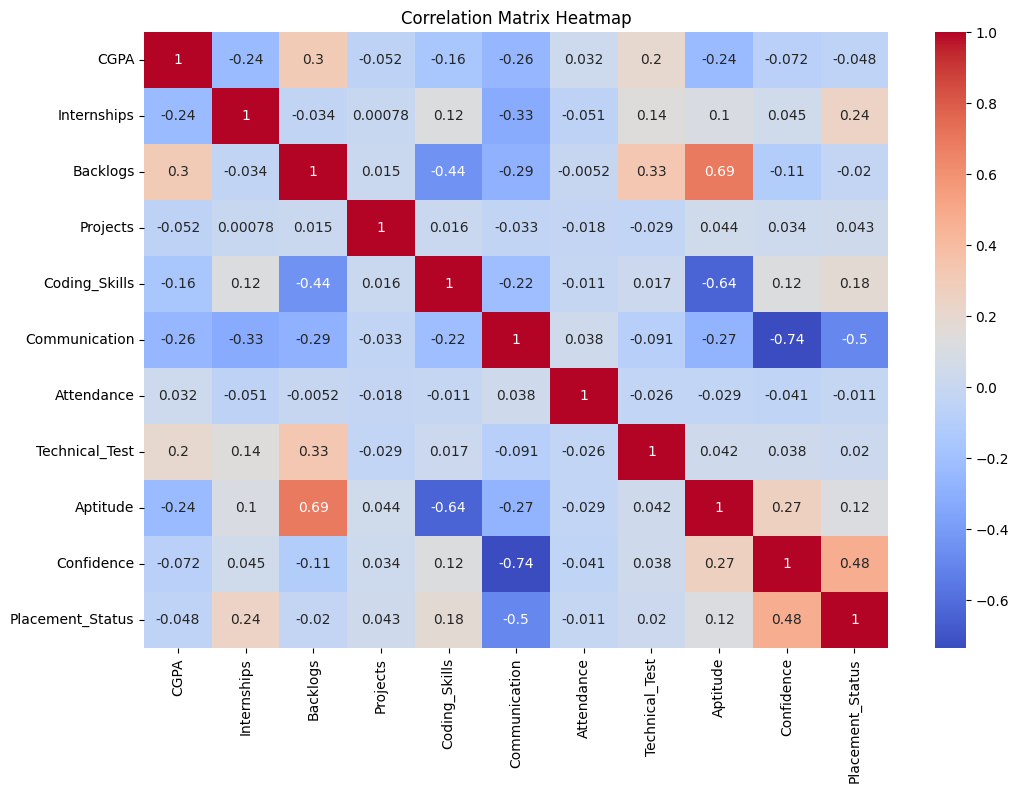

In [12]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Executive Summary

## Top 3 Insights
1. Students with strong coding skills and high CGPA are more likely to secure placements.
2. Technical test performance shows a strong relationship with placement outcomes.
3. The dataset is imbalanced, meaning predictive models should carefully handle minority classes.